In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('listings.csv')
df2 = pd.read_csv('listings1.csv')

df


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,27262,"AQA-No7, Great mattress, high speed internet",37177,Emmanouil,NaN,ΑΜΠΕΛΟΚΗΠΟΙ,37.989240,23.765000,Entire home/apt,NaN,1,29,2024-11-18,0.18,1,0,4,00002433111
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,NaN,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.006730,23.727750,Entire home/apt,45.0,4,89,2025-09-06,0.49,1,269,16,00000874421
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.976700,23.730640,Entire home/apt,160.0,2,142,2025-07-22,0.83,3,72,2,00000876484
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,NaN,ΣΤΑΔΙΟ,37.967380,23.740380,Entire home/apt,50.0,6,37,2025-07-31,0.29,1,54,5,00000508830
4,134340,Neo Pagrati Athens Apartment,659406,Konstantinos,NaN,ΠΑΓΚΡΑΤΙ,37.964050,23.749680,Entire home/apt,NaN,3,61,2025-07-22,0.36,1,0,6,00002821300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15579,1517487888239654553,P28 Suite 109,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983260,23.725160,Entire home/apt,50.0,1,0,NaN,NaN,10,349,0,00002937625
15580,1517500089629177426,P28 Suite 108,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983740,23.723970,Entire home/apt,51.0,1,0,NaN,NaN,10,355,0,00002937571
15581,1517507288743285688,P28 Suite 103,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983440,23.723920,Entire home/apt,51.0,1,0,NaN,NaN,10,350,0,00002937524
15582,1517516598039809920,P28 Suite 101,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983630,23.724000,Entire home/apt,51.0,1,0,NaN,NaN,10,352,0,00002937444


Data cleaning

In [3]:
df.dropna(thresh=3,inplace=True)
df2.dropna(thresh=3,inplace=True)
df



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,27262,"AQA-No7, Great mattress, high speed internet",37177,Emmanouil,NaN,ΑΜΠΕΛΟΚΗΠΟΙ,37.989240,23.765000,Entire home/apt,NaN,1,29,2024-11-18,0.18,1,0,4,00002433111
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,NaN,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.006730,23.727750,Entire home/apt,45.0,4,89,2025-09-06,0.49,1,269,16,00000874421
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.976700,23.730640,Entire home/apt,160.0,2,142,2025-07-22,0.83,3,72,2,00000876484
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,NaN,ΣΤΑΔΙΟ,37.967380,23.740380,Entire home/apt,50.0,6,37,2025-07-31,0.29,1,54,5,00000508830
4,134340,Neo Pagrati Athens Apartment,659406,Konstantinos,NaN,ΠΑΓΚΡΑΤΙ,37.964050,23.749680,Entire home/apt,NaN,3,61,2025-07-22,0.36,1,0,6,00002821300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15579,1517487888239654553,P28 Suite 109,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983260,23.725160,Entire home/apt,50.0,1,0,NaN,NaN,10,349,0,00002937625
15580,1517500089629177426,P28 Suite 108,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983740,23.723970,Entire home/apt,51.0,1,0,NaN,NaN,10,355,0,00002937571
15581,1517507288743285688,P28 Suite 103,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983440,23.723920,Entire home/apt,51.0,1,0,NaN,NaN,10,350,0,00002937524
15582,1517516598039809920,P28 Suite 101,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983630,23.724000,Entire home/apt,51.0,1,0,NaN,NaN,10,352,0,00002937444


In [5]:
df2.duplicated().sum()


np.int64(0)

In [4]:
df.isnull().sum()
df.dropna()
df.dropna(subset=['price', 'host_name'], inplace=True)
df.isnull().sum()
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,NaN,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.006730,23.727750,Entire home/apt,45.0,4,89,2025-09-06,0.49,1,269,16,00000874421
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.976700,23.730640,Entire home/apt,160.0,2,142,2025-07-22,0.83,3,72,2,00000876484
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,NaN,ΣΤΑΔΙΟ,37.967380,23.740380,Entire home/apt,50.0,6,37,2025-07-31,0.29,1,54,5,00000508830
5,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,741851,Yagos,NaN,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.985740,23.733230,Entire home/apt,70.0,2,225,2025-09-07,1.30,1,347,14,00000532953
6,155654,"Acropolis Cosy Apartment, Koukaki",712602,Nikos,NaN,ΑΚΡΟΠΟΛΗ,37.968280,23.729060,Entire home/apt,57.0,2,65,2023-10-14,0.47,2,0,0,00000429243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15579,1517487888239654553,P28 Suite 109,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983260,23.725160,Entire home/apt,50.0,1,0,NaN,NaN,10,349,0,00002937625
15580,1517500089629177426,P28 Suite 108,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983740,23.723970,Entire home/apt,51.0,1,0,NaN,NaN,10,355,0,00002937571
15581,1517507288743285688,P28 Suite 103,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983440,23.723920,Entire home/apt,51.0,1,0,NaN,NaN,10,350,0,00002937524
15582,1517516598039809920,P28 Suite 101,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983630,23.724000,Entire home/apt,51.0,1,0,NaN,NaN,10,352,0,00002937444


In [7]:
df2.isnull().sum()
df2.dropna()
df2.dropna(subset=['price', 'host_name'], inplace=True)
df2.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group               4319
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                        468
reviews_per_month                  468
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                             22
dtype: int64

In [8]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,NaN,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.006730,23.727750,Entire home/apt,45.0,4,89,2025-09-06,0.49,1,269,16,00000874421
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.976700,23.730640,Entire home/apt,160.0,2,142,2025-07-22,0.83,3,72,2,00000876484
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,NaN,ΣΤΑΔΙΟ,37.967380,23.740380,Entire home/apt,50.0,6,37,2025-07-31,0.29,1,54,5,00000508830
5,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,741851,Yagos,NaN,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.985740,23.733230,Entire home/apt,70.0,2,225,2025-09-07,1.30,1,347,14,00000532953
6,155654,"Acropolis Cosy Apartment, Koukaki",712602,Nikos,NaN,ΑΚΡΟΠΟΛΗ,37.968280,23.729060,Entire home/apt,57.0,2,65,2023-10-14,0.47,2,0,0,00000429243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15579,1517487888239654553,P28 Suite 109,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983260,23.725160,Entire home/apt,50.0,1,0,NaN,NaN,10,349,0,00002937625
15580,1517500089629177426,P28 Suite 108,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983740,23.723970,Entire home/apt,51.0,1,0,NaN,NaN,10,355,0,00002937571
15581,1517507288743285688,P28 Suite 103,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983440,23.723920,Entire home/apt,51.0,1,0,NaN,NaN,10,350,0,00002937524
15582,1517516598039809920,P28 Suite 101,678257512,Tasos Iason,NaN,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.983630,23.724000,Entire home/apt,51.0,1,0,NaN,NaN,10,352,0,00002937444


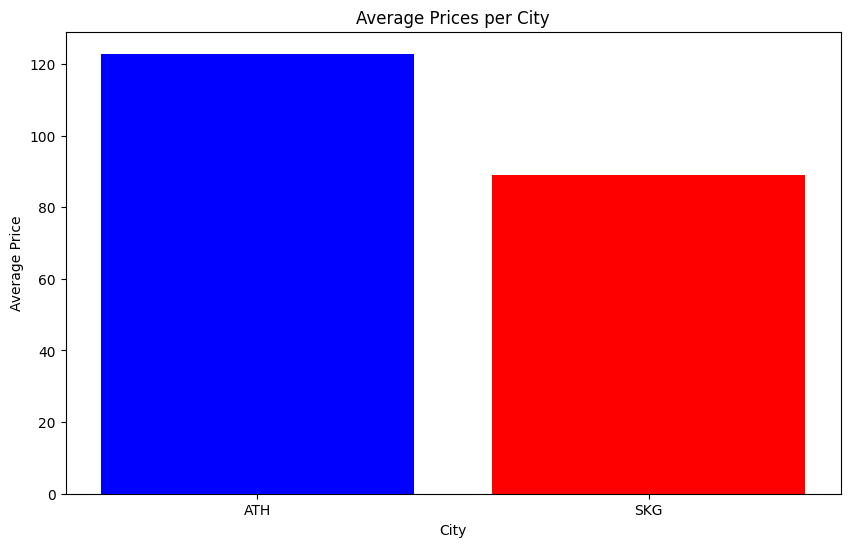

In [9]:
plt.figure(figsize = (10,6))

avg_ath = df['price'].mean()
avg_skg = df2['price'].mean()

plt.bar(['ATH', 'SKG'], [avg_ath, avg_skg], color=['blue', 'red'])

plt.title('Average Prices per City')
plt.xlabel('City')
plt.ylabel('Average Price')
plt.show()

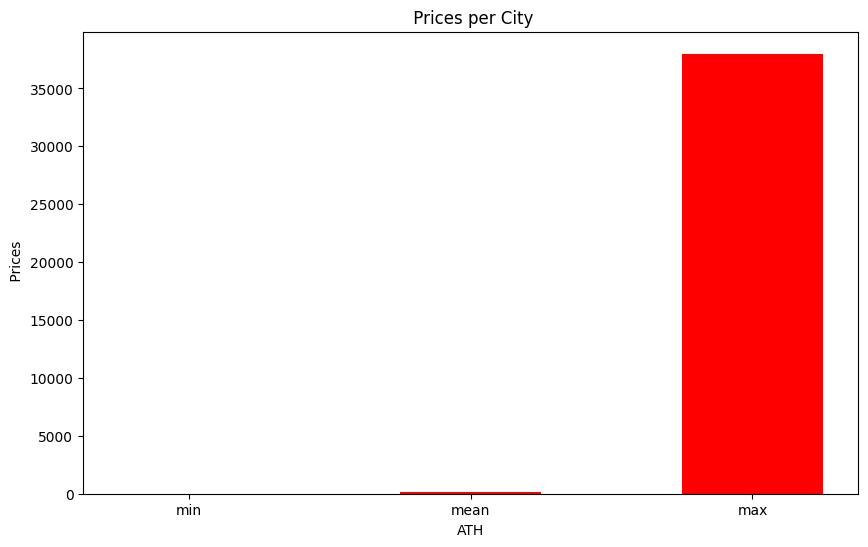

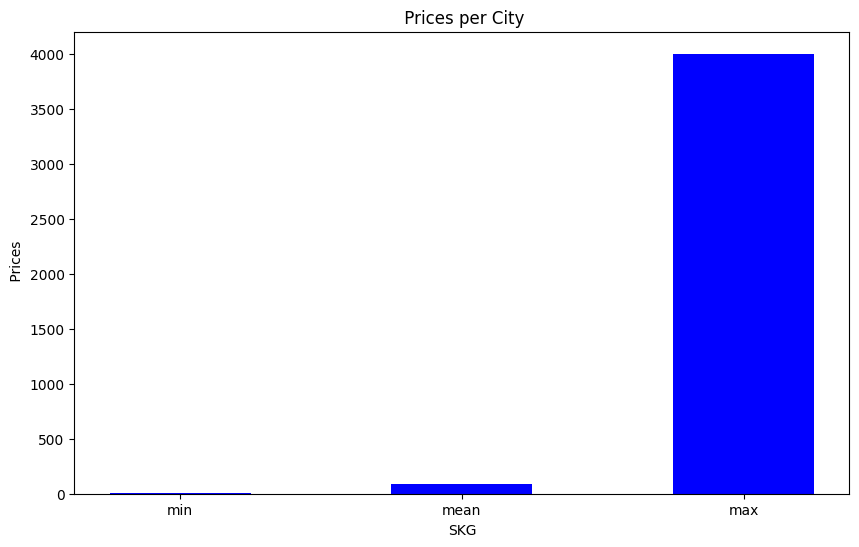

In [ ]:
plt.figure(figsize = (10,6))

avg_ath = df['price'].mean()
min_ath = df['price'].min()
max_ath = df['price'].max()
avg_skg = df2['price'].mean()
min_skg = df2['price'].min()
max_skg = df2['price'].max()
labels = ['min', 'mean', 'max']
cities = ['SKG' , 'ATH']
#plt.bar(['ATH', 'SKG'], [avg_ath, avg_skg], color=['blue', 'red'])
category_skg=[min_skg, avg_skg, max_skg]
category_ath=[min_ath, avg_ath, max_ath]

x=np.arange(len(labels))
#plt.bar(x-0.5,category_ath,width = 0.5 , label = 'ATH',color='red')
#plt.bar(x,category_skg,width = 0.5 , label = 'SKG',color='blue'))

plt.bar(labels,category_ath,width=0.5,label = 'ATH' , color='red')

plt.title(' Prices per City')
plt.xlabel('ATH')
plt.ylabel(' Prices')
plt.show()
plt.figure(figsize = (10,6))


plt.bar(labels,category_skg,width=0.5,label = 'SKG' , color='blue')

plt.title(' Prices per City')
plt.xlabel('SKG')
plt.ylabel(' Prices')
plt.show()

In [ ]:
plt.bar(labels,category_skg,width=0.5,label = 'SKG' , color='blue')


In [22]:
print(df2['price'].max())
print(df['price'].max())
print(df2['price'].min())
print(df['price'].min())


3999.0
38000.0
10.0
9.0


ithasoutliers

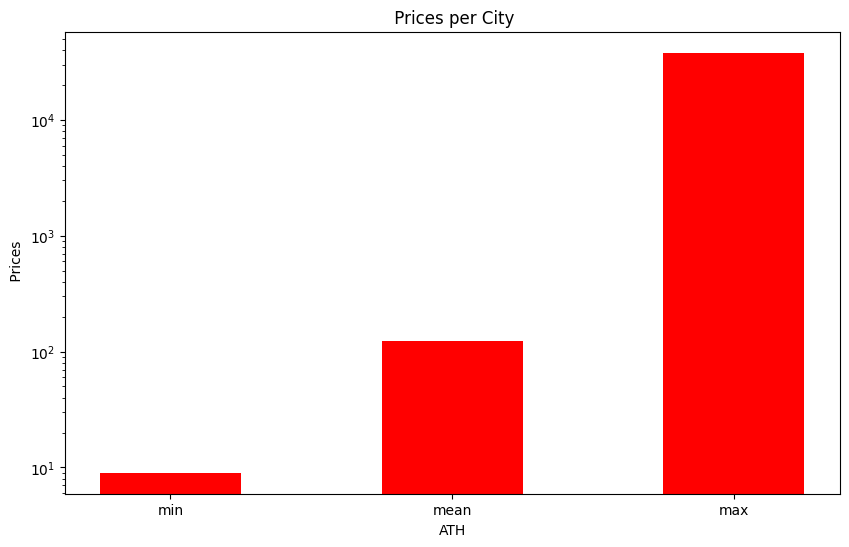

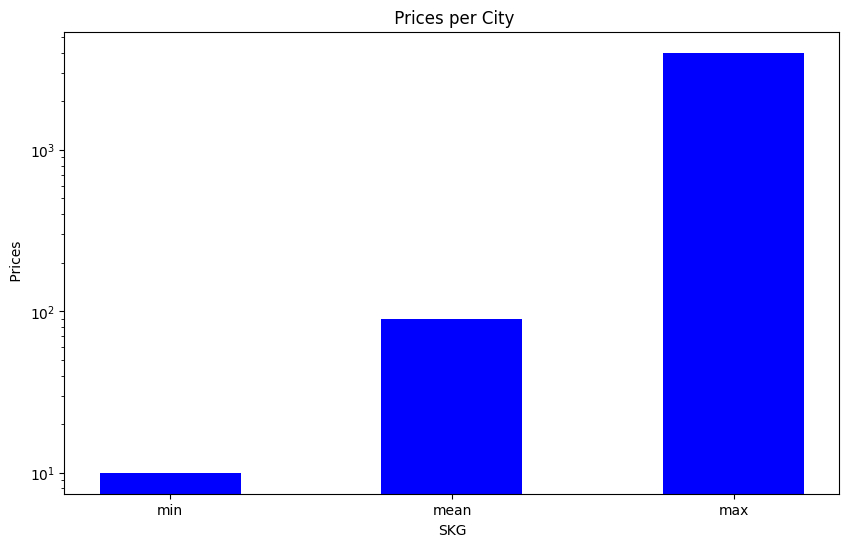

In [30]:
plt.figure(figsize = (10,6))

avg_ath = df['price'].mean()
min_ath = df['price'].min()
max_ath = df['price'].max()
avg_skg = df2['price'].mean()
min_skg = df2['price'].min()
max_skg = df2['price'].max()
labels = ['min', 'mean', 'max']
cities = ['SKG' , 'ATH']
#plt.bar(['ATH', 'SKG'], [avg_ath, avg_skg], color=['blue', 'red'])
category_skg=[min_skg, avg_skg, max_skg]
category_ath=[min_ath, avg_ath, max_ath]

x=np.arange(len(labels))
#plt.bar(x-0.5,category_ath,width = 0.5 , label = 'ATH',color='red')
#plt.bar(x,category_skg,width = 0.5 , label = 'SKG',color='blue'))

plt.bar(labels,category_ath,width=0.5,label = 'ATH' , color='red')

plt.yscale('log')
plt.title(' Prices per City')
plt.xlabel('ATH')
plt.ylabel(' Prices')
plt.show()
plt.figure(figsize = (10,6))


plt.bar(labels,category_skg,width=0.5,label = 'SKG' , color='blue')

plt.yscale('log')
plt.title(' Prices per City')
plt.xlabel('SKG')
plt.ylabel(' Prices')
plt.show()


εκτιμώμενα ελάχιστα έσοδα 

Αντιπροσωπεύει το συνολικό τζίρο
 που θα γινόταν αν κάθε διαθέσιμο ακίνητο στην πλατφόρμα κάθε πόλης
είχε ακριβώς μία κράτηση με τη μικρότερη δυνατή διάρκεια.

In [6]:
est_revenueath_total = (df['price'] * df['minimum_nights']).sum()

print(est_revenueath_total)

est_revenueskg_total = (df2['price'] * df2['minimum_nights']).sum()

print(est_revenueskg_total)

3665575.0
4214950.0


In [11]:
df2['minimum_nights'].max()


np.int64(900)

In [10]:
df['minimum_nights'].max()


np.int64(444)

In [12]:
print("Μέσο έσοδο ανά κράτηση στην Αθήνα:", (df['price'] * df['minimum_nights']).mean())
print("Μέσο έσοδο ανά κράτηση στη Θεσσαλονίκη:", (df2['price'] * df2['minimum_nights']).mean())

Μέσο έσοδο ανά κράτηση στην Αθήνα: 252.554430205319
Μέσο έσοδο ανά κράτηση στη Θεσσαλονίκη: 975.9087751794397


##  Ανάλυση και Εντοπισμός Ακραίων Τιμών (Outliers)

Κατά τον υπολογισμό του Estimated Revenue, παρατηρήθηκε μια παράδοξη διαφορά: η **Θεσσαλονίκη** εμφάνιζε υψηλότερο συνολικό τζίρο από την **Αθήνα**, παρά το γεγονός ότι οι μέσες τιμές ανά διανυκτέρευση στην Αθήνα είναι υψηλότερες.

### Το Φαινόμενο των Outliers στο `minimum_nights`
Η αιτία του φαινομένου εντοπίστηκε στη στήλη `minimum_nights`. Η μαθηματική πράξη για το έσοδο βασίζεται στον τύπο:
$$Estimated\ Revenue = Price \times Minimum\ Nights$$

Όπως προέκυψε από τον έλεγχο:
* Στη **Θεσσαλονίκη**, η μέγιστη τιμή του `minimum_nights` ανέρχεται στις **900 ημέρες**.
* Στην **Αθήνα**, η αντίστοιχη μέγιστη τιμή είναι **444 ημέρες**.


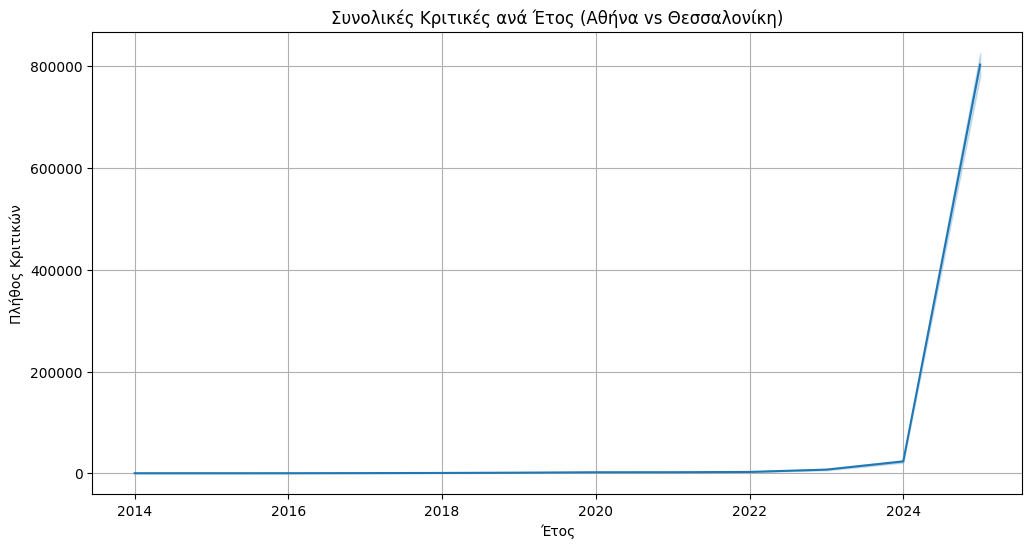

In [ ]:
# Μετατρέπουμε τη στήλη last_review σε ημερομηνία
df['last_review'] = pd.to_datetime(df['last_review'])

# Δημιουργούμε μια νέα στήλη μόνο για το Έτος
df['year'] = df['last_review'].dt.year

# Αφαιρούμε τις εγγραφές που δεν έχουν ημερομηνία (κενά)
df_clean = df.dropna(subset=['year'])

# 3. Δημιουργία Γραφήματος
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='year', y='number_of_reviews', estimator='sum')

plt.title('Συνολικές Κριτικές ανά Έτος (Αθήνα vs Θεσσαλονίκη)')
plt.xlabel('Έτος')
plt.ylabel('Πλήθος Κριτικών')
plt.grid(True)
plt.show()

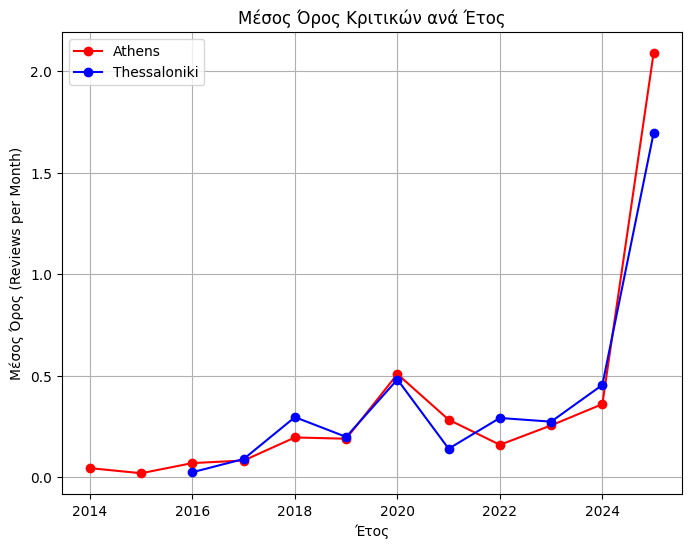

In [29]:
# 1. Μετατροπή ημερομηνίας και εξαγωγή έτους
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['year'] = df['last_review'].dt.year


df2['last_review'] = pd.to_datetime(df2['last_review'], errors='coerce')
df2['year'] = df2['last_review'].dt.year
# 2. ΟΜΑΔΟΠΟΙΗΣΗ: Υπολογίζουμε τον μέσο όρο των κριτικών ανά έτος
# Χρησιμοποιούμε το 'reviews_per_month' που είχες στον κώδικα ή το 'number_of_reviews'
df_grouped = df.groupby('year')['reviews_per_month'].mean().reset_index()

df2_grouped = df2.groupby('year')['reviews_per_month'].mean().reset_index()

# 3. Σχεδίαση Γραφήματος
plt.figure(figsize=(8, 6))

# Τώρα το x (year) και το y (reviews) έχουν το ίδιο μέγεθος!
plt.plot(df_grouped['year'], df_grouped['reviews_per_month'], marker='o', linestyle='-', color='r',label = 'Athens')

plt.plot(df2_grouped['year'], df2_grouped['reviews_per_month'], marker='o', linestyle='-', color='b', label ='Thessaloniki')


plt.title('Μέσος Όρος Κριτικών ανά Έτος')
plt.xlabel('Έτος')
plt.ylabel('Μέσος Όρος (Reviews per Month)')
plt.grid(True)
plt.legend()
plt.show()